# Natural Language Processing. Assignment 1. Tokenization.

In this assignment, you need to implement, train, and analyze a Byte-Pair Encoding (BPE) tokenizer.

The assignment consist of 3 tasks. When you finish all the tasks, create a GitHub repository for this assignment (you can use this repository later for the other assignments) and submit this notebook in the repository. Leave `requirements.txt` file if your code requires additional installations. Submit the link to the repository in Moodle.

## Task 1: Data Preparation and Vocabulary Size Selection (3 points)

First, load the [Brown corpus](https://en.wikipedia.org/wiki/Brown_Corpus). After loading the corpus, you need to select the appropriate vocabulary size for the BPE tokenizer. The appropriate vocabulary size is the minimal vocabulary size that covers at least 90% of the words in the corpus. The coverage is calculated according to the following formula:



$$ \text{coverage}(k) = \frac{\sum_{r=1}^{k} f(r)}{\sum_{r=1}^{N} f(r)} $$



where $f(r)$ is the frequency of the top-$r$ word, $k$ is the number of top-$k$ tokens included in vocab, $N$ is the total unique words in corpus.

So, for this task you need to do the following:

1. Load the Brown corpus (0.5 points)
2. Plot cumulative coverage vs. vocabulary size for the loaded corpus (1 point)
3. Select the appropriate vocabulary size (0.5 point)
4. Answer the questions:
    1. Why the coverage slows down the increase as the vocabulary size increases? (0.5 point)
    2. Which empirical law explains the slowing down increase of the coverage? (0.5 point)

In [1]:
import nltk
from nltk.corpus import brown
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [2]:
# 1.1 Download the Brown corpus
nltk.download('brown')

[nltk_data] Downloading package brown to /Users/rail/nltk_data...
[nltk_data]   Package brown is already up-to-date!


True

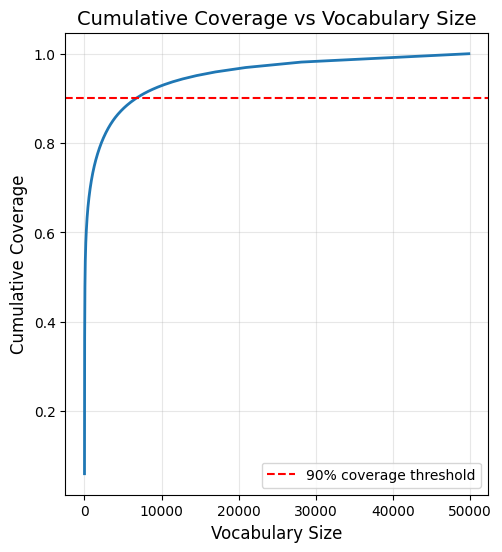

In [3]:
# 1.2 Plot cumulative coverage vs voab size
words = brown.words()
words_lower = [word.lower() for word in words]
word_freq = Counter(words_lower)

sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

vocab_sizes = []
coverages = []

total_word_count = sum(word_freq.values())

cumulative_count = 0
for k in range(1, len(sorted_words) + 1):
    cumulative_count += sorted_words[k-1][1]
    coverage = cumulative_count / total_word_count
    
    vocab_sizes.append(k)
    coverages.append(coverage)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(vocab_sizes, coverages, linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% coverage threshold')
plt.xlabel('Vocabulary Size', fontsize=12)
plt.ylabel('Cumulative Coverage', fontsize=12)
plt.title('Cumulative Coverage vs Vocabulary Size', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [5]:
# 1.3 Select the appropriate vocabulary size
target_coverage = 0.90
appropriate_vocab_size = next(k for k, cov in zip(vocab_sizes, coverages) if cov >= target_coverage)

print(f"Appropriate Vocabulary Size: {appropriate_vocab_size}")
print(f"Coverage at this size: {coverages[appropriate_vocab_size-1]:.4f}")

Appropriate Vocabulary Size: 6671
Coverage at this size: 0.9000


### 1.4.1 Why the coverage slows down the increase as the vocabulary size increases?

The coverage slows down because of the heavily skewed distribution of word frequencies in natural language. A small number of words (like "the", "a", "is", "of") appear very frequently and account for a large portion of the corpus. As we add more words to the vocabulary, we're adding increasingly rare words that contribute less and less to the overall coverage. For example, the most frequent word might appear 10,000 times, while the 10,000th most frequent word might appear only once or twice (Zipf's law). Therefore, adding the first 100 words to the vocabulary dramatically increases coverage, but adding words ranked 10,000-10,100 barely moves the coverage needle.

### 1.4.2. Which empirical law explains the slowing down increase of the coverage?

**Zipf's Law** explains this phenomenon. Zipf's Law states that the frequency of a word is inversely proportional to its rank in the frequency table. Mathematically: f(r) ~ 1/r^a, where f(r) is the frequency of the word at rank r, and a is close to 1 for natural language. This means the most frequent word appears roughly twice as often as the second most frequent word, three times as often as the third, and so on.

## Task 2: Implement Byte-Pair Encoding (BPE) Tokenizer (4 points)

Implement the [BPE tokenizer](https://arxiv.org/pdf/1508.07909) as the `BPETokenizer` class.

The class should contain correctly implemented:

* `train` method (1.5 points).
* `tokenize` method (1.5 points).

The code should have docstrings and comments (1 point).

In [6]:
from collections import Counter, defaultdict
from typing import List, Tuple, Dict


class BPETokenizer:
    """Byte-Pair Encoding tokenizer implementation."""
    
    def __init__(self, vocab_size: int):
        """Initializes tokenizer with target vocabulary size."""
        self.vocab_size = vocab_size
        self.vocab = set()
        self.merges = []
        self.token_freqs = {}
    
    def train(self, corpus: List[str]):
        """
        Performs train process for BPE tokenizer on corpus.
        
        Args:
            corpus: List of words to train on
        """

        # initialize with character-level vocabulary
        vocab = self._get_words_with_frequencies(corpus)
        
        self.vocab = set()
        for word in vocab.keys():
            self.vocab.update(word)
        
        initial_vocab_size = len(self.vocab)
        
        # perform merge operations until target vocab size reached
        num_merges = self.vocab_size - initial_vocab_size
        
        for i in range(num_merges):
            pairs = self._get_pair_frequencies(vocab)
            
            if not pairs:
                print(f"No more pairs to merge at iteration {i}")
                break
                
            # select most frequent pair
            best_pair = max(pairs.items(), key=lambda x: x[1])
            pair, freq = best_pair
            
            # apply merge
            vocab = self._merge_pair(pair, vocab)
            self.merges.append(pair)
            
            merged_token = ''.join(pair)
            self.vocab.add(merged_token)
        
    
    def _get_words_with_frequencies(self, corpus: List[str]) -> Counter:
        """Converts corpus to character-level words with frequencies."""
        word_freq = Counter(corpus)

        vocab = {}
        for word, freq in word_freq.items():
            chars = tuple(list(word) + ['</w>'])
            vocab[chars] = freq
        return vocab
    
    def _get_pair_frequencies(self, vocab: Dict[Tuple[str, ...], int]) -> Dict[Tuple[str, str], int]:
        """Counts frequency of adjacent token pairs in vocabulary."""
        pairs = defaultdict(int)
        
        for word, freq in vocab.items():
            for i in range(len(word) - 1):
                pair = (word[i], word[i + 1])
                pairs[pair] += freq
                
        return pairs
    
    def _merge_pair(self, pair: Tuple[str, str], vocab: Dict[Tuple[str, ...], int]) -> Dict[Tuple[str, ...], int]:
        """Merges all occurrences of pair in vocabulary."""
        new_vocab = {}
        bigram = ''.join(pair)
        
        for word, freq in vocab.items():
            new_word = []
            i = 0
            
            # replace all pair occurrences with merged token
            while i < len(word):
                if i < len(word) - 1 and word[i] == pair[0] and word[i + 1] == pair[1]:
                    new_word.append(bigram)
                    i += 2
                else:
                    new_word.append(word[i])
                    i += 1
                    
            new_vocab[tuple(new_word)] = freq
            
        return new_vocab
    
    def tokenize(self, text: str) -> List[str]:
        """
        Tokenizes text using trained BPE.
        
        Args:
            text: Input text to tokenize
            
        Returns:
            List of tokens
        """
        if not self.merges:
            raise ValueError("Tokenizer has not been trained yet. Call train() first.")
        
        words = text.lower().split()
        tokens = []
        
        for word in words:
            word_tokens = list(word) + ['</w>']
            
            # handling unknown characters
            word_tokens = [t if t in self.vocab or t == '</w>' else '<UNK>' 
                      for t in word_tokens]

            # applying learned merges in order
            for pair in self.merges:
                i = 0
                while i < len(word_tokens) - 1:
                    if word_tokens[i] == pair[0] and word_tokens[i + 1] == pair[1]:
                        merged = ''.join(pair)
                        word_tokens = word_tokens[:i] + [merged] + word_tokens[i+2:]
                    else:
                        i += 1
            
            tokens.extend(word_tokens)
        
        return tokens

## Task 3: Tokenizer Training and Analysis (3 points)

1. Train the `BPETokenizer` on the Brown corpus with the appropriate vocabulary size selected in Task 1 (1 points)
2. Use the Brown corpus (1000 samples) to calculate the mean and standard deviation of
    * tokenizer's fertility (1 points)
    * length of the tokenized sentence (1 points)

In [ ]:
# 3.1  Train BPE Tokenizer on Brown corpus 
# runs in about 5-6 minutes on my machine
training_corpus = list(words_lower)
bpe_tokenizer = BPETokenizer(vocab_size=appropriate_vocab_size)
bpe_tokenizer.train(training_corpus)

print(f"Voacb size after training: {len(bpe_tokenizer.vocab)}")
print(f"Number of merge operations: {len(bpe_tokenizer.merges)}")

Voacb size after training: 6671
Number of merge operations: 6613


Tokenizer Fertility:
  Mean: 1.2496
  Std:  0.2132
Tokenized Sentence Length:
  Mean: 25.39 tokens
  Std:  18.03 tokens


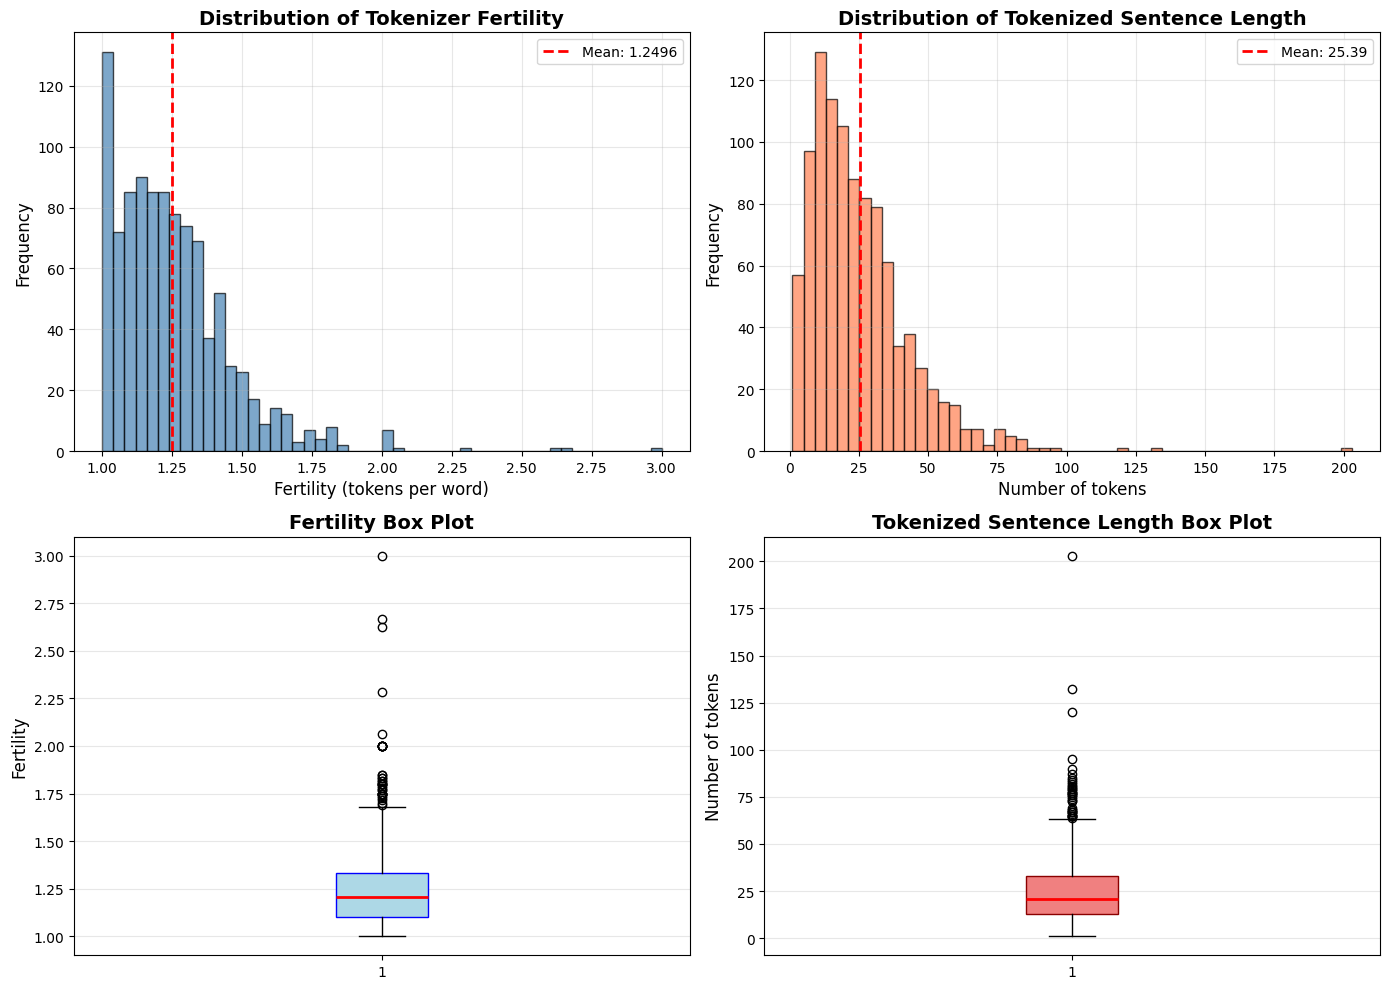

In [8]:
# 3.2 tokenizer analysis
import random
all_brown_sentences = list(brown.sents())

random.seed(42)
sampled_sentences = random.sample(all_brown_sentences, min(1000, len(all_brown_sentences)))

sentences_text = [' '.join(sent).lower() for sent in sampled_sentences]


fertilities = []
tokenized_lengths = []

for sentence in sentences_text:
    original_words = sentence.split()
    num_words = len(original_words)
    
    tokens = bpe_tokenizer.tokenize(sentence)
    num_tokens = len(tokens)
    
    if num_words > 0:
        fertility = num_tokens / num_words
        fertilities.append(fertility)
    
    tokenized_lengths.append(num_tokens)

mean_fertility = np.mean(fertilities)
std_fertility = np.std(fertilities)

mean_length = np.mean(tokenized_lengths)
std_length = np.std(tokenized_lengths)

print(f"Tokenizer Fertility:")
print(f"  Mean: {mean_fertility:.4f}")
print(f"  Std:  {std_fertility:.4f}")
print(f"Tokenized Sentence Length:")
print(f"  Mean: {mean_length:.2f} tokens")
print(f"  Std:  {std_length:.2f} tokens")


# Visualization of the results

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Fertility distribution
axes[0, 0].hist(fertilities, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(mean_fertility, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_fertility:.4f}')
axes[0, 0].set_xlabel('Fertility (tokens per word)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Tokenizer Fertility', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Tokenized sentence length distribution
axes[0, 1].hist(tokenized_lengths, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].axvline(mean_length, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_length:.2f}')
axes[0, 1].set_xlabel('Number of tokens', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Distribution of Tokenized Sentence Length', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Box plot for fertility
axes[1, 0].boxplot(fertilities, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='blue'),
                    medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_ylabel('Fertility', fontsize=12)
axes[1, 0].set_title('Fertility Box Plot', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Box plot for sentence length
axes[1, 1].boxplot(tokenized_lengths, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', color='darkred'),
                    medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_ylabel('Number of tokens', fontsize=12)
axes[1, 1].set_title('Tokenized Sentence Length Box Plot', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Grading Procedure Details

During the grading of the completed assignments, a random set of students will be sampled for the **offline assignment defence**. The defence will be arranged shortly after the assignment submission deadline. The particular date and time will be announced later. 

The aim of the assignment defence is to ensure the students understand well their own solutions and know how thier solution works. To check this, the students will be asked various questions about the provided solution. In addition, the students will be asked to run their solution to ensure the solution works without errors.

Examples of questions:

1. How the cumulative coverage is calculated? Why is it called cumulative?
2. What is the rank of a word?
3. How does the BPE tokenizer work? Note: for this question, the students will not be able to see the their own implementation.
4. Why do you consider such vocabulary size appropriate?
5. What is the formula for the fertility of the tokenizer?
6. How do you perform pre-tokenization in your implementation?
7. How do you handle stopwords in the training corpus? Why?
8. etc.

As a result of the assignment defence, the grade for the assignment may be adjusted.